In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

Tasodifiy nuqtalar klasterini yaratish uchun `make_blobs` funksiyasidan foydalanamiz. Bu funksiya quyidagi parametrlarni qabul qiladi:
- `n_samples` - nuqtalar soni
- `centers` - klasterlar markazi (sentroid) koordinatalari
-`cluster_std` - markazdan standart og'ish

`make_blobs` funksiyasi nuqtalarning `x` va `y` koordinatalarini qaytaradi.

In [24]:
np.random.seed(0)
centroids = [[3,3], [-3, -2], [2, -3], [0, 0], [4,-4], [-4,-6], [-5, 0], [-2, 6]]
X, y = make_blobs(n_samples=5000, centers=centroids, cluster_std=0.8)

Nuqtalarni chizamiz:

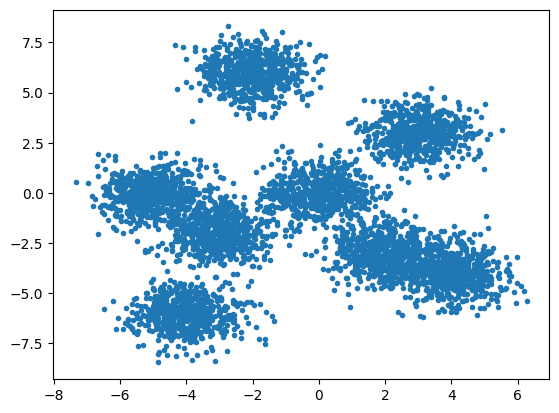

In [25]:
plt.scatter(X[:, 0], X[:, 1], marker='.')
plt.show()

### k-means algoritmi
`KMeans` funksiyasi quyidagi parametrlarni qabul qiladi:
- `init` - sentrodilarni tanlash usuli (`k-means++` yoki `random`)
- `n_clusters` - klastertlar soni
- `n_init` - algoritmni necha marta ishga tushirish (turli sentroidlar bilan qayta-qayta ishga tushirib, modelni qurishni boshlash uchun eng yaxshi sentroidlar tanlanadi)

`KMeans` boshqa parametrlari haqida rasmiy sahifasidan ma'lumot olasiz: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

In [4]:
k_means = KMeans(init = "random", n_clusters = 4, n_init = 15)

Modelni tarbiyalaymiz

In [5]:
k_means.fit(X)

KMeans(init='random', n_clusters=4, n_init=15)

Nuqtalar klasterlandi. Klaster raqamini ko'rish uchun `.labels_` parametriga murojaat qilamiz.

In [6]:
k_means.labels_

array([3, 1, 1, ..., 2, 3, 3], dtype=int32)

Klaster markazlarini ko'rich uchun `.cluster_centers_` parametriga murojaat qilamiz.

In [7]:
k_means.cluster_centers_

array([[-3.05006801e-02,  1.12353254e-03],
       [ 1.99348887e+00, -3.01067931e+00],
       [ 2.97795387e+00,  2.99317691e+00],
       [-3.01979724e+00, -1.99489798e+00]])

Algoritm topgan klaster markazlarini, biz avvaldan bergan markazlar bilan solishtiramiz:

In [8]:
print(centroids)

[[3, 3], [-3, -2], [2, -3], [0, 0]]


Deyarli bir xil. Butunlab ko'ramiz:

In [9]:
print(np.round(k_means.cluster_centers_))

[[-0.  0.]
 [ 2. -3.]
 [ 3.  3.]
 [-3. -2.]]


### Grafik chizamiz

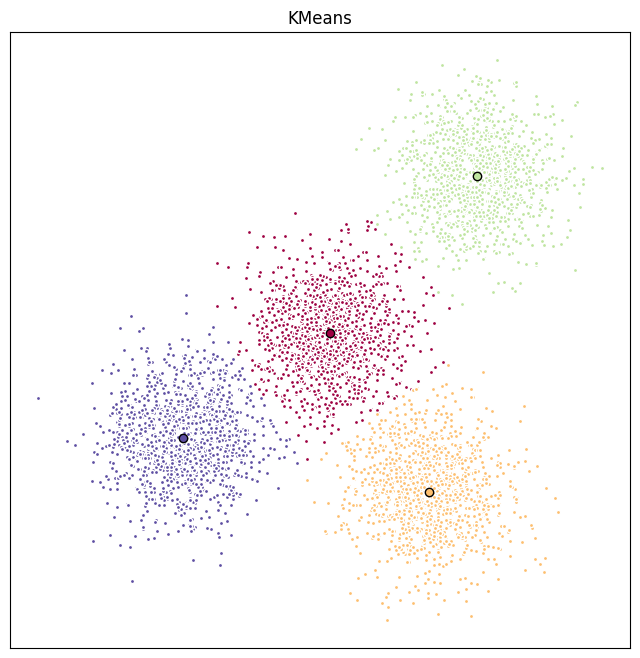

In [10]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))
ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[3,3], [-3, -2], [2, -3], [0, 0]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means.labels_ == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means.cluster_centers_[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

## VAZIFA
`KMeans` algoritmini turli `k` (klasterlar soni) va boshqa `init` parametri (`k-means++`) bilan ishga tushirib ko'ring.

In [26]:
# Kutilgan natija
k_means = KMeans(init="k-means++", n_clusters = 8, n_init=15)
k_means.fit(X)

KMeans(n_init=15)

In [27]:
k_means.labels_

array([2, 7, 6, ..., 3, 1, 2], dtype=int32)

In [28]:
k_means.cluster_centers_

array([[-2.03546487,  5.97763946],
       [ 0.02885258,  0.02956521],
       [ 1.91661271, -2.98007093],
       [-3.02425673, -2.00211385],
       [ 3.00189551,  2.9737778 ],
       [-5.04409431, -0.01549377],
       [ 4.08361213, -4.05894384],
       [-4.00309154, -6.02619972]])

In [29]:
print(centroids)

[[3, 3], [-3, -2], [2, -3], [0, 0], [4, -4], [-4, -6], [-5, 0], [-2, 6]]


In [30]:
print(np.round(k_means.cluster_centers_))

[[-2.  6.]
 [ 0.  0.]
 [ 2. -3.]
 [-3. -2.]
 [ 3.  3.]
 [-5. -0.]
 [ 4. -4.]
 [-4. -6.]]


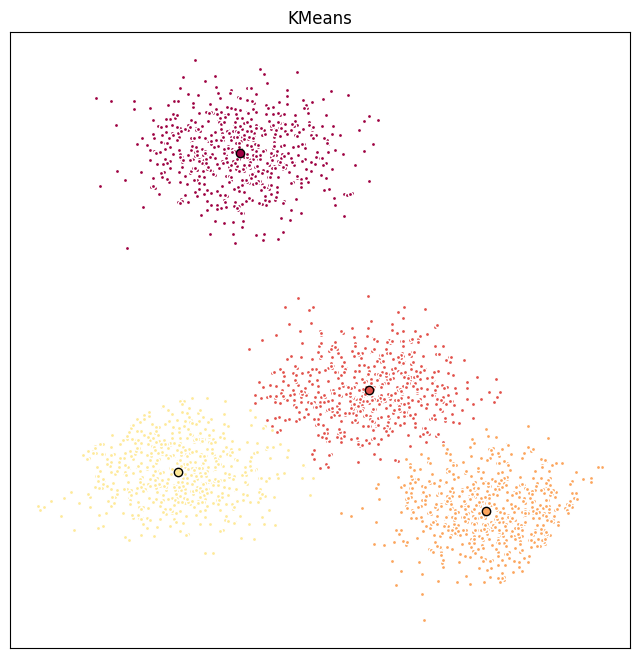

In [31]:
fig = plt.figure(figsize=(8, 8))
# Har bir klaster uchun alohida rang
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))
ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[3,3], [-3, -2], [2, -3], [0, 0]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means.labels_ == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means.cluster_centers_[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()